In [2]:
from PIL import Image
from vangogh.evolution import Evolution, generate_initial_seed_edgebased
from vangogh.fitness import draw_voronoi_image
from vangogh.util import IMAGE_SHRINK_SCALE, REFERENCE_IMAGE, NUM_POINTS, SEED, POP_SIZE
from IPython.display import display, clear_output
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from time import time
from mpl_toolkits.axes_grid1 import ImageGrid
import os

plt.style.use('classic')
%matplotlib inline

from multiprocess import Pool, cpu_count

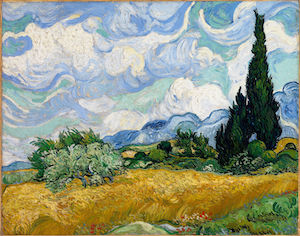

In [3]:
display(REFERENCE_IMAGE)

In [4]:
from vangogh.util import REFERENCE_POINTS

# Enable to show live rendering of best individual during optimization
display_output = False
# Enable to save progress images at every 50th generation
save_progress = True
# Enable to print verbose output per generation
verbose_output = False

# # Generate once
# initial_gene = generate_initial_seed_edgebased(REFERENCE_IMAGE, REFERENCE_POINTS, NUM_POINTS, seed=SEED)
# # Repeat across the population
# INITIAL_POPULATION = np.repeat(initial_gene, repeats=POP_SIZE, axis=0)

In [5]:
def reporter(time, evo):
    if save_progress or display_output:
        elite = draw_voronoi_image(evo.elite, evo.reference_image.width, evo.reference_image.height, scale=IMAGE_SHRINK_SCALE)
    if display_output:
        clear_output()
        display(elite)
    if save_progress and time["num-generations"] % 50 == 0:
        elite.save(f"./img/van_gogh_intermediate_{evo.seed}_{evo.population_size}_{evo.crossover_method}_{evo.num_points}_{evo.initialization}_{evo.generation_budget}_{time['num-generations']:05d}.png")

def run_algorithm(settings):
    seed, population_size, crossover_method, num_points, initialization, generation_budget = settings
    start = time()

    evo = Evolution(num_points,
                    REFERENCE_IMAGE,
                    population_size=population_size,
                    generation_reporter=reporter,
                    crossover_method=crossover_method,
                    seed=seed,
                    initialization=initialization,
                    generation_budget=generation_budget,
                    num_features_mutation_strength=.25,
                    selection_name='tournament_4',
                    verbose=verbose_output)
    data = evo.run()

    time_spent = time() - start

    for d in data:
        d["seed"] = seed
        d["population_size"] = population_size
        d["crossover_method"] = crossover_method
        d["num_points"] = num_points
        d["initialization"] = initialization
        d["generation_budget"] = generation_budget
        d["time_spent"] = time_spent

    df = pd.DataFrame(data)
    output_dir = "csv_files_greybox_edgebased"
    os.makedirs(output_dir, exist_ok=True)
    file_path = os.path.join(output_dir, f"run_seed_{seed}_{REFERENCE_POINTS}_{NUM_POINTS-REFERENCE_POINTS}.csv")
    df.to_csv(file_path, index=False)


    # print(f"Done: run {seed} - pop {population_size} - crossover {crossover_method} - num. points {num_points} - initialization {initialization} - in {int(time_spent)} seconds")
    
    return data

## Running a single instance

In [ ]:
%%time
data = run_algorithm((55, 100, "ONE_POINT", 100, 'RANDOM', 500))

## Running a sweep of settings

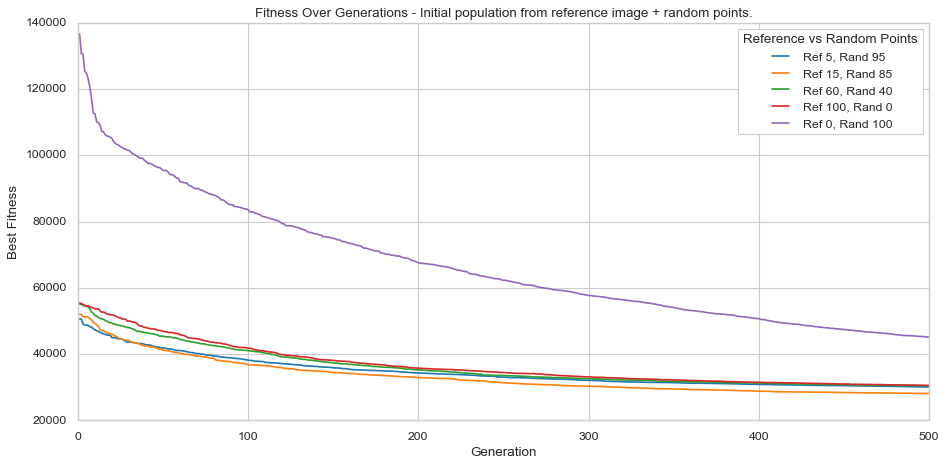

In [3]:
import matplotlib.pyplot as plt
import os
import re

sns.set_theme(style="whitegrid", palette="tab10")

selected_filenames = [
    "run_seed_55_5_95.csv",
    "run_seed_55_15_85.csv",
    "run_seed_55_60_40.csv",
    "run_seed_55_100_0.csv",
    "run_seed_55_0_100.csv"
]

from pathlib import Path

csv_files = [Path("csv_files_greybox_edgebased") / fname for fname in selected_filenames]


dfs = []

for file_path in csv_files:
    # Example filename: run_seed_55_5_95.csv
    filename = os.path.basename(file_path)
    match = re.match(r"run_seed_\d+_(\d+)_(\d+)\.csv", filename)

    if match:
        ref_points = int(match.group(1))
        rand_points = int(match.group(2))

        df = pd.read_csv(file_path)
        df["REFERENCE_POINTS"] = ref_points
        df["RANDOM_POINTS"] = rand_points
        df["label"] = df.apply(lambda row: f"Ref {ref_points}, Rand {rand_points}", axis=1)

        dfs.append(df)

# Combine all DataFrames
df_all = pd.concat(dfs, ignore_index=True)

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_all, x="num-generations", y="best-fitness", hue="label")

plt.title("Fitness Over Generations - Initial population from reference image + random points.")
plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.legend(title="Reference vs Random Points")
plt.tight_layout()
plt.show()



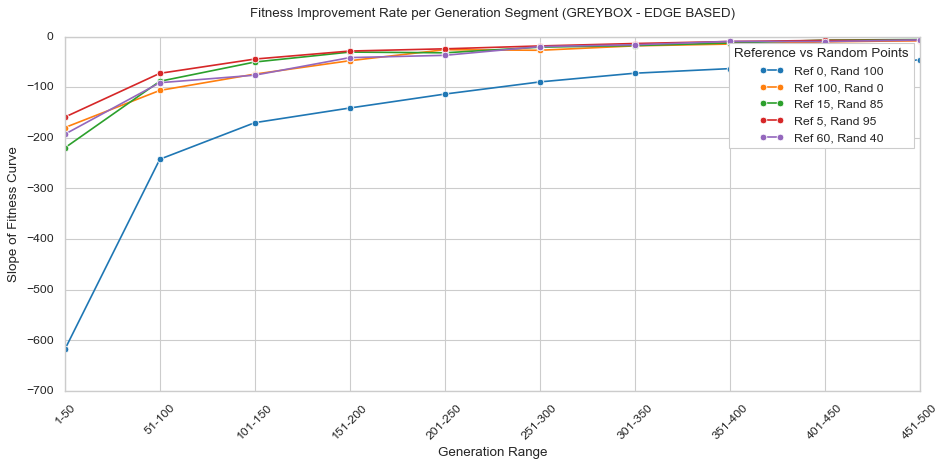

In [6]:
from scipy.stats import linregress
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import re
from glob import glob

sns.set_theme(style="whitegrid", palette="tab10")

# --- Load all CSVs ---
selected_filenames = [
    "run_seed_55_5_95.csv",
    "run_seed_55_15_85.csv",
    "run_seed_55_60_40.csv",
    "run_seed_55_100_0.csv",
    "run_seed_55_0_100.csv"
]

from pathlib import Path

csv_files = [Path("csv_files_greybox_edgebased") / fname for fname in selected_filenames]
dfs = []

for file_path in csv_files:
    filename = os.path.basename(file_path)
    match = re.match(r"run_seed_\d+_(\d+)_(\d+)\.csv", filename)

    if match:
        ref_points = int(match.group(1))
        rand_points = int(match.group(2))

        df = pd.read_csv(file_path)
        df["REFERENCE_POINTS"] = ref_points
        df["RANDOM_POINTS"] = rand_points
        df["label"] = df.apply(lambda row: f"Ref {ref_points}, Rand {rand_points}", axis=1)

        dfs.append(df)

# Combine all DataFrames
df_all = pd.concat(dfs, ignore_index=True)

# --- Compute slope segments ---
bin_size = 50
bins = list(range(0, 551, bin_size))  # [0, 50, 100, ..., 500]

slope_segments = []

# For each (label, seed), compute slope
for (label, seed), group in df_all.groupby(["label", "seed"]):
    for i in range(len(bins) - 1):
        start_gen = bins[i] + 1
        end_gen = bins[i + 1]
        segment = group[(group["num-generations"] >= start_gen) & (group["num-generations"] <= end_gen)]

        if len(segment) >= 2:
            slope = linregress(segment["num-generations"], segment["best-fitness"]).slope
            slope_segments.append({
                "label": label,
                "seed": seed,
                "gen_range": f"{start_gen}-{end_gen}",
                "slope": slope
            })

# Convert to DataFrame
slope_df = pd.DataFrame(slope_segments)

# --- Plot ---
plt.figure(figsize=(12, 6))
sns.lineplot(data=slope_df, x="gen_range", y="slope", hue="label", marker="o")

plt.title("Fitness Improvement Rate per Generation Segment (GREYBOX - EDGE BASED)\n")
plt.xlabel("Generation Range")
plt.ylabel("Slope of Fitness Curve")
plt.xticks(rotation=45)
plt.axhline(0, linestyle='--', color='gray')
plt.legend(title="Reference vs Random Points")
plt.tight_layout()
plt.show()


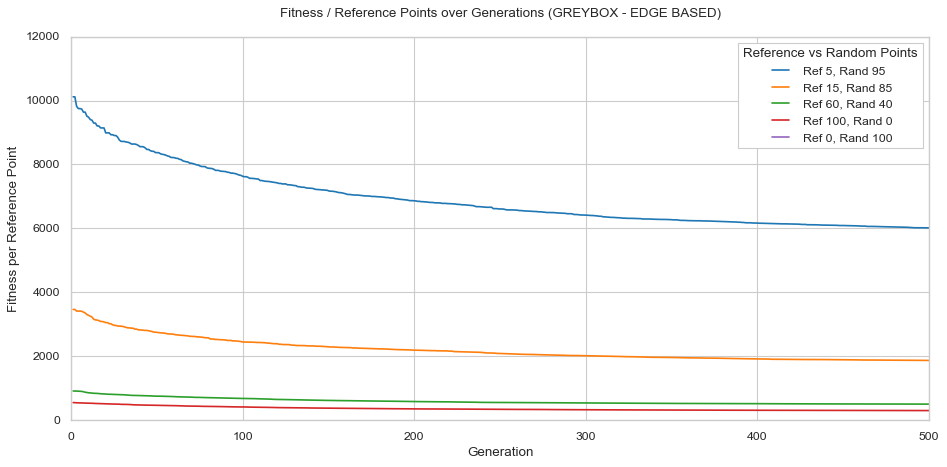

In [10]:
from scipy.stats import linregress
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import re
from glob import glob

sns.set_theme(style="whitegrid", palette="tab10")
selected_filenames = [
    "run_seed_55_5_95.csv",
    "run_seed_55_15_85.csv",
    "run_seed_55_60_40.csv",
    "run_seed_55_100_0.csv",
    "run_seed_55_0_100.csv"
]

from pathlib import Path

csv_files = [Path("csv_files_greybox_edgebased") / fname for fname in selected_filenames]
dfs = []


for file_path in csv_files:
    filename = os.path.basename(file_path)
    match = re.match(r"run_seed_\d+_(\d+)_(\d+)\.csv", filename)

    if match:
        ref_points = int(match.group(1))
        rand_points = int(match.group(2))

        df = pd.read_csv(file_path)
        df["REFERENCE_POINTS"] = ref_points
        df["RANDOM_POINTS"] = rand_points
        df["label"] = df.apply(lambda row: f"Ref {ref_points}, Rand {rand_points}", axis=1)

        # Compute fitness / reference_points
        df["fitness_per_ref_point"] = df["best-fitness"] / df["REFERENCE_POINTS"]

        dfs.append(df)

# Combine all DataFrames
df_all = pd.concat(dfs, ignore_index=True)

# Optional: select specific generations to make graph cleaner
# You can remove this filter if you want full curves.
# selected_generations = [50, 100, 200, 300, 400, 500]
# df_plot = df_plot[df_plot["num-generations"].isin(selected_generations)]

# --- Plot ---
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_all, x="num-generations", y="fitness_per_ref_point", hue="label")

plt.title("Fitness / Reference Points over Generations (GREYBOX - EDGE BASED)\n")
plt.xlabel("Generation")
plt.ylabel("Fitness per Reference Point")
plt.legend(title="Reference vs Random Points")
plt.tight_layout()
plt.show()


In [9]:

## Displaying the best instances over time
def show_progress_over_time(settings, selection=None, grid=(5,4)):
    seed, population_size, crossover_method, num_points, generation_budget = settings
    fig = plt.figure(figsize=(20., 20.))
    grid = ImageGrid(fig, 111,
                     nrows_ncols=grid,
                     axes_pad=0.1,  # pad between axes
                     )

    if selection is None:
        selection = range(50, generation_budget + 50, 50)

    img_arr = [Image.open(
        f"./img/van_gogh_intermediate_{seed}_{population_size}_{crossover_method}_{num_points}_GREYBOX_{generation_budget}_{i:05d}.png") for i in selection]
    for ax, im in zip(grid, img_arr):
        ax.imshow(im)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    plt.show()

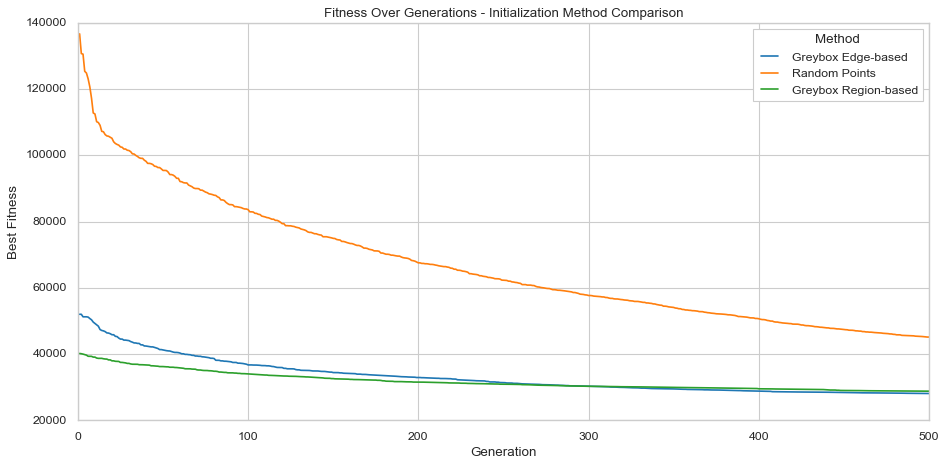

In [15]:
import matplotlib.pyplot as plt
import os
import re

label_mapping = {
    "15_85": "Greybox Edge-based",
    "90_10": "Greybox Region-based",
    "0_100": "Random Points"
}

sns.set_theme(style="whitegrid", palette="tab10")

selected_filenames_1 = [
    "run_seed_55_15_85.csv",
    "run_seed_55_0_100.csv",
]

selected_filenames_2 = [
    "run_seed_55_90_10.csv"
]

# Two directories
dir1 = Path("csv_files_greybox_edgebased")
dir2 = Path("csv_files_graybox_regionbased")

# Combine paths for both directories
csv_files = [dir1 / fname for fname in selected_filenames_1] + [dir2 / fname for fname in selected_filenames_2]

dfs = []

for file_path in csv_files:
    # Example filename: run_seed_55_5_95.csv
    filename = os.path.basename(file_path)
    match = re.match(r"run_seed_\d+_(\d+)_(\d+)\.csv", filename)

    if match:
        ref_points = int(match.group(1))
        rand_points = int(match.group(2))
        pattern_key = f"{ref_points}_{rand_points}"

        df = pd.read_csv(file_path)
        df["REFERENCE_POINTS"] = ref_points
        df["RANDOM_POINTS"] = rand_points

        # Map to method label
        method_label = label_mapping.get(pattern_key, "unknown")
        df["method"] = method_label

        dfs.append(df)

# Combine all DataFrames
df_all = pd.concat(dfs, ignore_index=True)

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_all, x="num-generations", y="best-fitness", hue="method")

plt.title("Fitness Over Generations - Initialization Method Comparison")
plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.legend(title="Method")
plt.tight_layout()
plt.show()




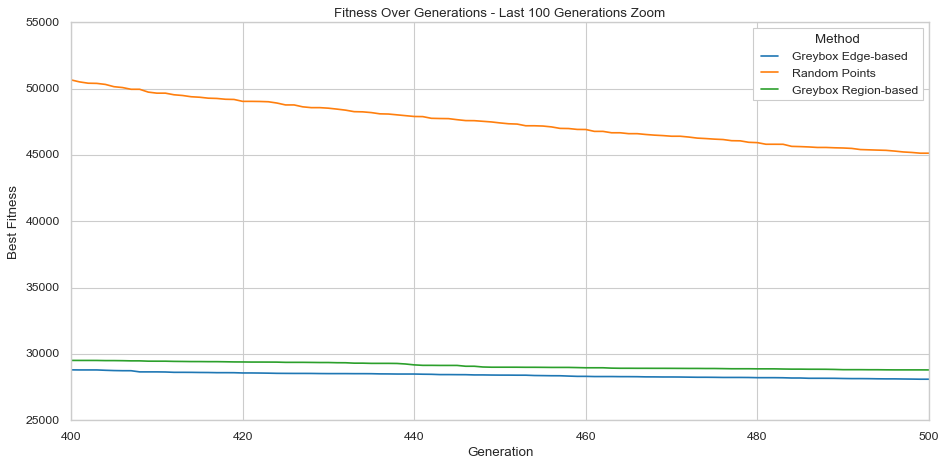

In [16]:
# Filter to last 100 generations
last_100_df = df_all[df_all["num-generations"] >= df_all["num-generations"].max() - 100]

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=last_100_df, x="num-generations", y="best-fitness", hue="method")

plt.title("Fitness Over Generations - Last 100 Generations Zoom")
plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.legend(title="Method")
plt.tight_layout()
plt.show()

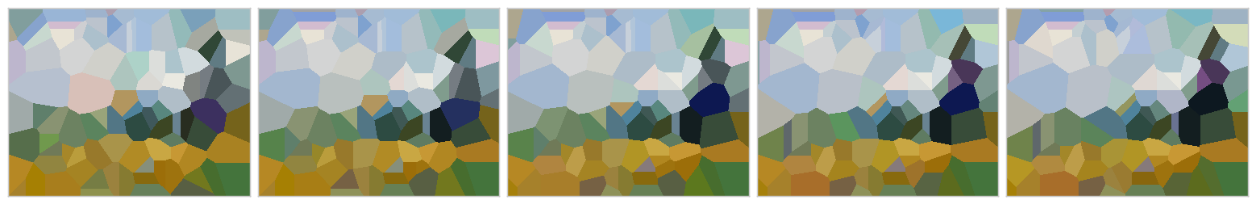

In [11]:
show_progress_over_time((42, 100, 'ONE_POINT', 100, 500), grid=(1,5))